In [ ]:
import os 
import json 

from pyddeeg.classification import EEGDataset
from pyddeeg.classification.engine.trainer import evaluate_frozen_models

from pathlib import Path

from sklearn.ensemble import HistGradientBoostingClassifier

PATH_OPTIMIZED = "/home/mariopasc/Python/Results/EEG/T7_window_1000_up"
with open(os.path.join(PATH_OPTIMIZED, "best_params.json"), 'r') as f:
    params = json.load(f)  # parse JSON into native Python objects

ds_root = Path("/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset")
window = "window_1000"
direction = "up"
seed = 42
elec = "T7"
base_estimator = HistGradientBoostingClassifier



dataset = EEGDataset.load(ds_root, window, direction, elec, random_state=seed)


results = evaluate_frozen_models(
    dataset=dataset,
    params_per_window=params,  
    base_estimator_cls=base_estimator,
    n_jobs_windows=10
)

/home/mariopasc/Python/misc/miniconda3/envs/pyddeeg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Folds: 100%|██████████| 5/5 [00:12<00:00,  2.47s/fold]


In [10]:
from pyddeeg.classification.engine.trainer import permutation_test_decision_scores

permutation_results = permutation_test_decision_scores(decision_scores=results["decision_scores"],
                                 labels=results["labels"], n_permutations=10000)

Using a threshold of 4.047100
stat_fun(H1): min=2.1508015899747888e-06 max=6.988033781663765
Running initial clustering …
Found 5 clusters


100%|██████████| Permuting : 9999/9999 [00:00<00:00, 14046.77it/s]


**Results**

In [51]:
import os

import numpy as np
import json
from pathlib import Path

from pyddeeg.classification import EEGDataset
from pyddeeg.classification.utils.basic_visualizations import plot_auc_and_selected_features

RESULTS = "/home/mariopasc/Python/Results/EEG/T7_window_500_up"

ds_root = Path("/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset")
window = "window_1000"
direction = "up"
seed = 42
elec = "T7"

dataset = EEGDataset.load(ds_root, window, direction, elec, random_state=seed)

cv_results = np.load(os.path.join(RESULTS, "cv_results.npz"), allow_pickle=True)
print(cv_results.files)

# plot_auc_and_selected_features(results=cv_results, dataset=dataset, show_colorbar=False)

cv_results["fold_auc"][:, 0, :][:, 5]

['decision_scores', 'labels', 'fold_auc', 'selected_features', 'params_per_window', 'cv_indices', 't_centres_ms']


array([0.5       , 0.5       , 0.5       , 0.5       , 0.38888889])

In [41]:
#!/usr/bin/env python3
"""
plot_optuna_auc_heatmap.py   (v3 – adds a 3-D surface option)

Visualise Optuna AUC-ROC results across windows & trials.

Usage
-----
    # 2-D heat-map (default behaviour)
    python plot_optuna_auc_heatmap.py <FOLDER>

    # Pareto scatter/line (as v2)
    python plot_optuna_auc_heatmap.py <FOLDER> --plot3d

    # NEW: running-best surface
    python plot_optuna_auc_heatmap.py <FOLDER> --surface
"""
from __future__ import annotations

import argparse
import re
from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import optuna                              # pip install optuna>=3.0
from mpl_toolkits.mplot3d import Axes3D     # noqa: F401  (registers 3-D proj)

# ────────────────────────────────────────────────────────────────────────────
#                           helpers (unchanged)                              #
# ────────────────────────────────────────────────────────────────────────────
_WIN_RE = re.compile(r"_win(\d+)\.db$")


def _extract_window_index(path: Path) -> int:
    m = _WIN_RE.search(path.name)
    if not m:
        raise ValueError(f"Cannot parse window index from {path.name}")
    return int(m.group(1))


def _load_study(path: Path) -> optuna.study.Study:
    storage_url = f"sqlite:///{path}"
    storage = optuna.storages.RDBStorage(url=storage_url)
    summaries = optuna.study.get_all_study_summaries(storage)
    if len(summaries) != 1:
        raise RuntimeError(f"Expected 1 study in {path}, found {len(summaries)}")
    return optuna.load_study(study_name=summaries[0].study_name, storage=storage)


def _collect_auc_matrix(folder: Path) -> Tuple[np.ndarray, List[int]]:
    """*Identical to v1/v2 – untouched.*"""
    db_paths = sorted(folder.glob("*.db"), key=_extract_window_index)
    if not db_paths:
        raise FileNotFoundError("No *.db files found in the given directory")

    auc_per_window: List[List[float]] = []
    best_trial_indices: List[int] = []

    for db in db_paths:
        study = _load_study(db)
        trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        trials.sort(key=lambda t: t.number)
        aucs = [float(t.value) for t in trials]
        auc_per_window.append(aucs)
        best_trial_indices.append(int(np.argmax(aucs)))

    max_trials = max(len(r) for r in auc_per_window)
    n_windows = len(db_paths)
    matrix = np.full((max_trials, n_windows), np.nan, dtype=float)
    for col, aucs in enumerate(auc_per_window):
        matrix[: len(aucs), col] = aucs
    return matrix, best_trial_indices


# ────────────────────────────────────────────────────────────────────────────
#                          plotting primitives                               #
# ────────────────────────────────────────────────────────────────────────────
def _plot_heatmap_with_best_line(matrix: np.ndarray, best_rows: List[int]) -> None:
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(matrix, origin="lower", aspect="auto")
    xs = np.arange(matrix.shape[1])
    ys = np.array(best_rows, dtype=float)
    ax.plot(xs, ys, marker="o", lw=2)
    ax.set_xlabel("Window index")
    ax.set_ylabel("Trial (row number)")
    fig.colorbar(im, ax=ax).set_label("AUC-ROC")
    ax.set_title("Optuna AUC-ROC per Trial & Window\n(overlay: best trial per window)")
    fig.tight_layout()
    plt.show()


# ---------- 3-D Pareto scatter/line (v2) -----------------------------------
def _pareto_points_for_column(col: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    valid = ~np.isnan(col)
    if not valid.any():
        return np.empty(0, dtype=int), np.empty(0, dtype=float)
    trials = np.where(valid)[0]
    aucs = col[trials]
    best_so_far = -np.inf
    keep_t, keep_a = [], []
    for t, v in zip(trials, aucs):
        if v > best_so_far:
            best_so_far = v
            keep_t.append(int(t))
            keep_a.append(float(v))
    return np.array(keep_t), np.array(keep_a)


def _plot_pareto_3d(matrix: np.ndarray) -> None:
    n_windows = matrix.shape[1]
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection="3d")
    for w in range(n_windows):
        trials, aucs = _pareto_points_for_column(matrix[:, w])
        if trials.size == 0:
            continue
        xs = np.full_like(trials, w, dtype=float)
        ax.scatter(xs, trials, aucs)
        ax.plot(xs, trials, aucs, lw=1.5)
    ax.set_xlabel("Window index")
    ax.set_ylabel("Trial")
    ax.set_zlabel("AUC-ROC")
    ax.set_title("Running-best (Pareto) AUC-ROC – scatter/line")
    fig.tight_layout()
    plt.show()
def _plot_boxplot_coloured(matrix: np.ndarray) -> None:
    """
    One box per window:
        * distribution of AUC-ROC across trials
        * box fill colour ↔ trial index where max AUC occurs
        * dot = max AUC point
    """
    n_trials, n_windows = matrix.shape
    # Gather per-window data & maxima
    data, max_vals, max_trials = [], [], []
    for w in range(n_windows):
        col = matrix[:, w]
        valid = col[~np.isnan(col)]
        data.append(valid)
        if valid.size:
            idx = int(np.nanargmax(col))
            max_trials.append(idx)
            max_vals.append(col[idx])
        else:          # entire column NaN
            max_trials.append(np.nan)
            max_vals.append(np.nan)

    # Normalise trial index → colour
    cmap = plt.get_cmap("viridis")
    trial_arr = np.array(max_trials, dtype=float)
    norm = plt.Normalize(vmin=0, vmax=np.nanmax(trial_arr) if np.isfinite(trial_arr).any() else 1)
    colours = [cmap(norm(t)) if np.isfinite(t) else (0.5, 0.5, 0.5, 0.3)  # grey for missing
               for t in trial_arr]

    # Plot
    fig, ax = plt.subplots(figsize=(max(12, n_windows * 0.1), 6)) # Adjust figure width based on number of windows
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6) # Increase box widths
    for patch, colour in zip(bp["boxes"], colours):
        patch.set_facecolor(colour)

    # Max-points
    xs = np.arange(1, n_windows + 1)
    ax.scatter(xs, max_vals, c=colours, edgecolors="k", zorder=3)

    # Labels
    ax.set_xlabel("Window index")
    ax.set_ylabel("AUC-ROC")
    ax.set_title("AUC-ROC distribution per window\\n"
                 "(colour = trial index of max AUC – dot marks the max)")

    # Set custom xticks
    tick_positions = np.linspace(1, n_windows, 15, dtype=int) # Calculate 6 tick positions (0, 1/5, ..., 1)
    tick_labels = [str(pos - 1) for pos in tick_positions] # Labels are 0-based window indices
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)


    # Colour-bar legend
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.15) # Add padding to colorbar
    cbar.set_label("Trial index of max AUC")

    fig.tight_layout(rect=[0, 0.05, 1, 1]) # Adjust layout to prevent overlap
    plt.savefig("boxplot_coloured.png", dpi=300, bbox_inches='tight') # Save figure
    plt.show()
# ---------- 3-D surface -----------------------------------------------------
def _running_best_matrix(matrix: np.ndarray) -> np.ndarray:
    """
    For each window (column) replace every AUC with the *best value up to
    that trial* (np.maximum.accumulate). NaNs are carried through.
    """
    filled = np.nan_to_num(matrix, nan=-np.inf)
    best = np.maximum.accumulate(filled, axis=0)
    best[best == -np.inf] = np.nan
    return best


def _plot_pareto_surface(matrix: np.ndarray) -> None:
    surf = _running_best_matrix(matrix)
    n_trials, n_windows = surf.shape
    X, Y = np.meshgrid(np.arange(n_windows), np.arange(n_trials))
    Z = np.ma.masked_invalid(surf)

    fig = plt.figure(figsize=(12, 8)) # Increased figure height slightly for colorbar
    ax = fig.add_subplot(111, projection="3d")

    # Normalize the Z values to map to colors
    norm = plt.Normalize(Z.min(), Z.max())
    colors = plt.cm.viridis(norm(Z)) # Use viridis colormap, can change if needed

    # Plot the surface with facecolors set based on Z values
    surf_plot = ax.plot_surface(X, Y, Z, facecolors=colors, cmap=plt.cm.viridis,
                                linewidth=0, antialiased=False, shade=False)

    # Add a color bar which maps values to colors
    fig.colorbar(surf_plot, shrink=0.5, aspect=5, label="Running-best AUC-ROC")

    ax.set_xlabel("Window index")
    ax.set_ylabel("Trial")
    ax.set_zlabel("Running-best AUC-ROC")
    ax.set_title("Running-best AUC-ROC – 3-D surface")
    fig.tight_layout()
    plt.show()


# ────────────────────────────────────────────────────────────────────────────
#                                    CLI                                     #
# ────────────────────────────────────────────────────────────────────────────
def main() -> None:
    p = argparse.ArgumentParser(description="Optuna AUC visualisations")
    p.add_argument("folder", type=Path, help="Directory with *.db Optuna studies")

    g = p.add_mutually_exclusive_group()
    g.add_argument("--plot3d", action="store_true",
                   help="3-D scatter/line Pareto view")
    g.add_argument("--surface", action="store_true",
                   help="3-D running-best surface")
    g.add_argument("--boxplot", action="store_true",
                   help="2-D box-plot per window coloured by best-trial index")

    args = p.parse_args()

    matrix, best_trials = _collect_auc_matrix(args.folder)

    if args.boxplot:
        _plot_boxplot_coloured(matrix)
    elif args.surface:
        _plot_pareto_surface(matrix)
    elif args.plot3d:
        _plot_pareto_3d(matrix)
    else:
        _plot_heatmap_with_best_line(matrix, best_trials)


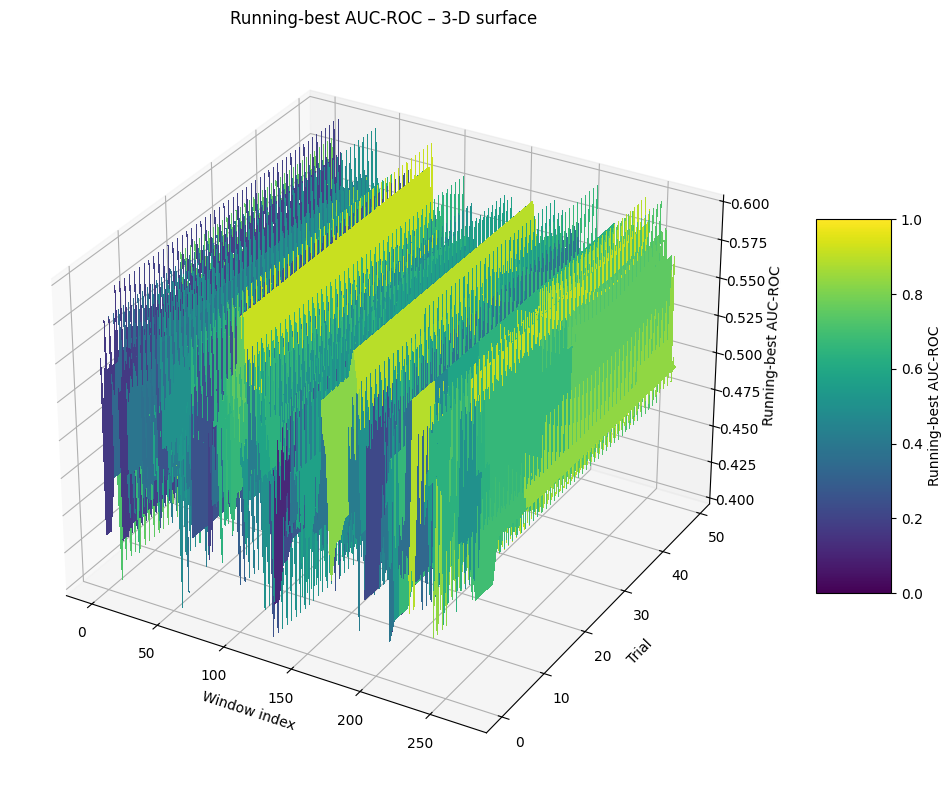

In [42]:
#matrix, best_trials = _collect_auc_matrix(Path(os.path.join(RESULTS, "optuna")))
_plot_pareto_surface(matrix)